In [24]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pypsa

In [7]:
dem = pd.read_csv(
    Path.cwd().parent / 'resources' / 'industrial_energy_demand_base_s_50_2030.csv',
    index_col=0, header=[0,1]
)
dem.columns.get_level_values(1).value_counts()

electricity                        2
naphtha                            2
current electricity                2
process emission from feedstock    2
process emission                   2
methanol                           2
coal                               2
ammonia                            2
low-temperature heat               2
hydrogen                           2
methane                            2
solid biomass                      2
coke                               2
fuel oil                           1
heat100-200                        1
heat200-500                        1
heat>500                           1
Name: count, dtype: int64

In [36]:
from tqdm import tqdm

# years = range(2025, 2036)
years = [2025, 2035]
vals = []

for y in tqdm(years):

    dems = pd.read_csv(
        Path.cwd().parent / 'resources' / f'industrial_energy_demand_base_s_50_{y}.csv',
        index_col=0, header=[0,1]
    ).sum()
    vals.append(dems.rename(y))

df = pd.concat(vals, axis=1)
df

100%|██████████| 2/2 [00:00<00:00, 180.52it/s]


2025     2035
exogenous  electricity                      1070.67  1373.61
           coal                               14.14     9.23
           coke                              354.79   160.74
           solid biomass                     367.20   527.05
           methane                          1175.32   751.84
           hydrogen                           -8.79    19.20
           low-temperature heat              185.60   127.74
           naphtha                           896.13   654.26
           ammonia                            87.30    87.30
           methanol                            8.74     8.74
           process emission                  190.27   167.13
           process emission from feedstock    22.87    18.80
           current electricity              1046.05  1046.05
endogenous low-temperature heat              448.55   436.05
           ammonia                            87.30    87.30
           solid biomass                       3.29     3.17
           coke                              372.54   283.15
           electricity                      1035.84  1066.53
           heat100-200                       555.32   537.45
           heat200-500                       129.49   125.58
           heat>500                          385.79   361.24
           hydrogen                           -9.18    16.32
           methane                           271.23   223.58
           naphtha                           912.32   793.13
           coal                                0.00     0.00
           methanol                            0.00     0.00
           process emission                    0.00     0.60
           process emission from feedstock     0.00     0.00
           current electricity              1046.05  1046.05

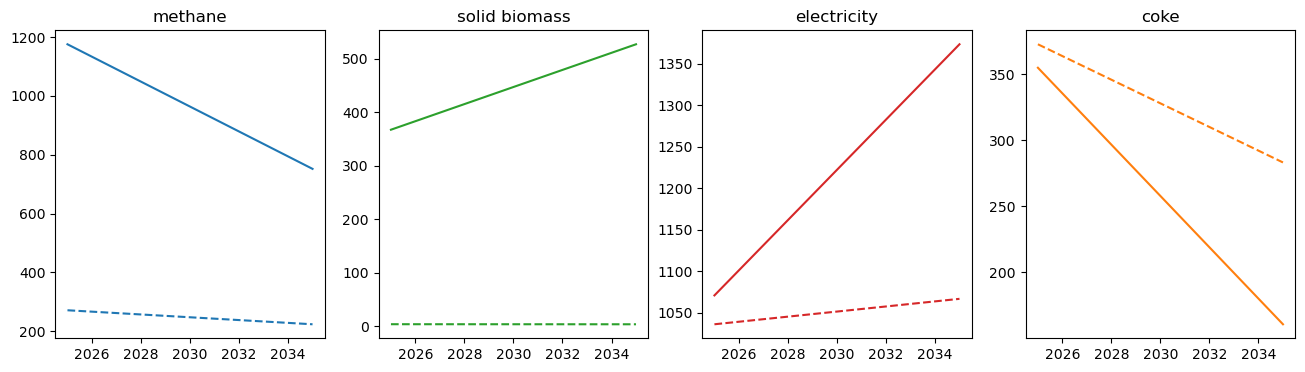

In [37]:
fig, axs = plt.subplots(1, 4, figsize=(16, 4))

colors = ['tab:blue', 'tab:green', 'tab:red', 'tab:orange']

for i, carrier in enumerate(['methane', 'solid biomass', 'electricity', 'coke']):

    ax = axs[i]
    c = colors[i]

    df.loc[('exogenous', carrier)].plot(ax=ax, color=c, linestyle='-')
    df.loc[('endogenous', carrier)].plot(ax=ax, color=c, linestyle='--')

    ax.set_title(carrier)

In [23]:
vals

[129.49,
 129.07999999999998,
 128.75,
 128.4,
 128.01000000000002,
 127.66999999999999,
 127.25,
 126.82,
 126.42,
 125.98,
 125.58]